# Задание
1. Загрузить текстовый корпус (Wiki или иной)
2. Обучить модель word2vec на этих данных
3. Построить карту эмбеддингов и визуализировать на 2d при помощи t-SNE
4. Выделить определенный класс слов (города, имена, цвета)
5. Посчитать отношения среднего расстояния межну элементами класса из п.4 к среднему расстоянию между всеми элементами корпуса

In [107]:
from datasets import load_dataset

# dataset = load_dataset("contextlab/dickens-corpus", data_files="1400.txt")
dataset = load_dataset("Amadeus99/wikipedia-subset-1k")

In [108]:
for i in range(10):
    print(dataset['train'][i]['text'])

Anarchism is a political philosophy and movement that is skeptical of all justifications for authority and seeks to abolish the institutions it claims maintain unnecessary coercion and hierarchy, typically including nation-states, and capitalism. Anarchism advocates for the replacement of the state with stateless societies and voluntary free associations. As a historically left-wing movement, this reading of anarchism is placed on the farthest left of the political spectrum, usually described as the libertarian wing of the socialist movement (libertarian socialism).

Humans have lived in societies without formal hierarchies long before the establishment of states, realms, or empires. With the rise of organised hierarchical bodies, scepticism toward authority also rose. Although traces of anarchist ideas are found all throughout history, modern anarchism emerged from the Enlightenment. During the latter half of the 19th and the first decades of the 20th century, the anarchist movement f

In [110]:
corpus = [text["text"].split() for text in dataset['train']]
print("Corpus before preprocessing: ", [corpus[i] for i in range(20)], sep='\n')

Corpus before preprocessing: 
[['Anarchism', 'is', 'a', 'political', 'philosophy', 'and', 'movement', 'that', 'is', 'skeptical', 'of', 'all', 'justifications', 'for', 'authority', 'and', 'seeks', 'to', 'abolish', 'the', 'institutions', 'it', 'claims', 'maintain', 'unnecessary', 'coercion', 'and', 'hierarchy,', 'typically', 'including', 'nation-states,', 'and', 'capitalism.', 'Anarchism', 'advocates', 'for', 'the', 'replacement', 'of', 'the', 'state', 'with', 'stateless', 'societies', 'and', 'voluntary', 'free', 'associations.', 'As', 'a', 'historically', 'left-wing', 'movement,', 'this', 'reading', 'of', 'anarchism', 'is', 'placed', 'on', 'the', 'farthest', 'left', 'of', 'the', 'political', 'spectrum,', 'usually', 'described', 'as', 'the', 'libertarian', 'wing', 'of', 'the', 'socialist', 'movement', '(libertarian', 'socialism).', 'Humans', 'have', 'lived', 'in', 'societies', 'without', 'formal', 'hierarchies', 'long', 'before', 'the', 'establishment', 'of', 'states,', 'realms,', 'or', 

In [111]:
from gensim.parsing.preprocessing import (
    preprocess_string,
    strip_punctuation,
    strip_numeric,
    strip_multiple_whitespaces,
    remove_stopwords,
    strip_short,
    lower_to_unicode,
)

filters = [
    lower_to_unicode,          
    strip_punctuation,         
    strip_numeric,    
    strip_short,         
    strip_multiple_whitespaces, 
    remove_stopwords,          
]

preprocessed_corpus = [
    preprocess_string(text["text"], filters)
    for text in dataset['train']
]

In [112]:
print("Corpus after preprocessing: ", [preprocessed_corpus[i] for i in range(20)], sep='\n')

Corpus after preprocessing: 
[['anarchism', 'political', 'philosophy', 'movement', 'skeptical', 'justifications', 'authority', 'seeks', 'abolish', 'institutions', 'claims', 'maintain', 'unnecessary', 'coercion', 'hierarchy', 'typically', 'including', 'nation', 'states', 'capitalism', 'anarchism', 'advocates', 'replacement', 'state', 'stateless', 'societies', 'voluntary', 'free', 'associations', 'historically', 'left', 'wing', 'movement', 'reading', 'anarchism', 'placed', 'farthest', 'left', 'political', 'spectrum', 'usually', 'described', 'libertarian', 'wing', 'socialist', 'movement', 'libertarian', 'socialism', 'humans', 'lived', 'societies', 'formal', 'hierarchies', 'long', 'establishment', 'states', 'realms', 'empires', 'rise', 'organised', 'hierarchical', 'bodies', 'scepticism', 'authority', 'rose', 'traces', 'anarchist', 'ideas', 'history', 'modern', 'anarchism', 'emerged', 'enlightenment', 'half', 'decades', 'century', 'anarchist', 'movement', 'flourished', 'parts', 'world', 'si

In [113]:
from gensim.models import Word2Vec

word2vec = Word2Vec(preprocessed_corpus, vector_size=100, workers=4, epochs=10, sg=1)
print(f"Dictionary size: {len(word2vec.wv.key_to_index)}")

Dictionary size: 31368


In [114]:
from sklearn.manifold import TSNE

tsne = TSNE(n_components=2, random_state=42, perplexity=10)

In [132]:
import numpy as np

words = list(word2vec.wv.index_to_key)[:800]
word_vectors = np.array([word2vec.wv[w] for w in words])
embeddings_2d = tsne.fit_transform(word_vectors)

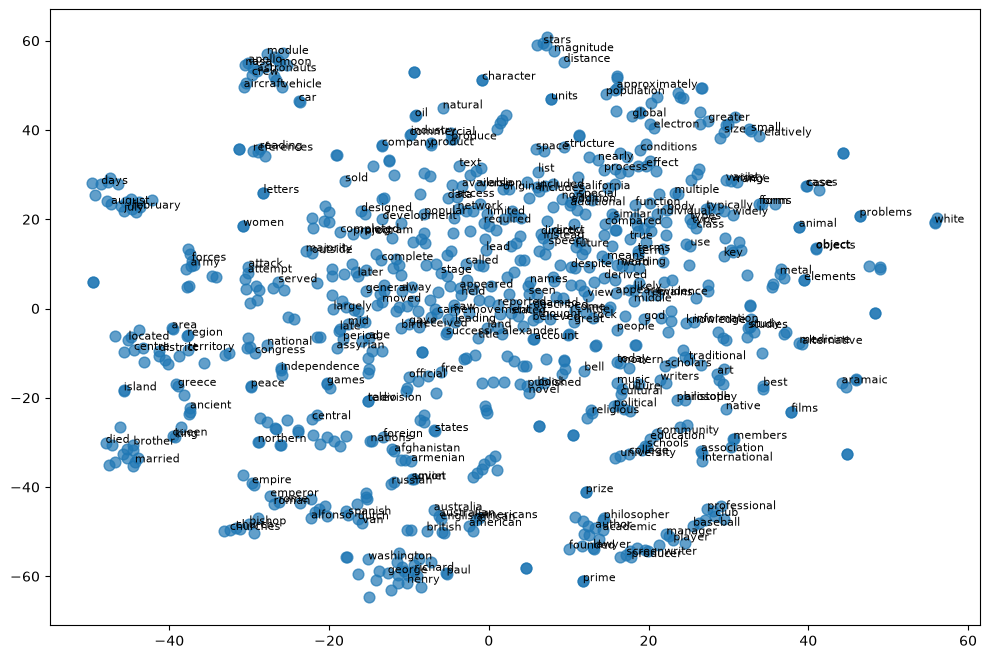

In [144]:
import matplotlib.pyplot as plt

plt.figure(figsize=(12, 8))
plt.scatter(embeddings_2d[:, 0], embeddings_2d[:, 1], s=60, alpha=0.7)

for i, word in enumerate(words):
    if i % 3 == 0:
        plt.annotate(word, (embeddings_2d[i, 0], embeddings_2d[i, 1]), fontsize=8)
        
plt.show()

In [139]:
anchor_names = ['paul', 'robert', 'michael', 'richard', 'george', 'henry']
# anchor_names = ['armenia', 'canada']
anchor_in_vocab = [w for w in anchor_names if w in word2vec.wv.key_to_index]

candidates = set(anchor_in_vocab)
for name in anchor_in_vocab:
    neighbors = word2vec.wv.most_similar(name, topn=10)
    for neighbor, score in neighbors:
        candidates.add(neighbor)

print(f"Candidates: {len(candidates)}")
print(sorted(candidates))

Candidates: 62
['alden', 'anthologist', 'apostle', 'baronet', 'bradshaw', 'broughton', 'buckingham', 'cass', 'charles', 'condon', 'cornelius', 'cowley', 'donnell', 'douglass', 'duncan', 'earl', 'edward', 'edwin', 'eric', 'falk', 'galloway', 'george', 'gillespie', 'gladstone', 'goff', 'goldschmidt', 'gurley', 'henry', 'hervey', 'hillary', 'houser', 'huntingdon', 'james', 'john', 'laurens', 'marcia', 'matthew', 'maurice', 'mcmaster', 'michael', 'montagu', 'neale', 'noel', 'norris', 'northumberland', 'orton', 'ozanam', 'paul', 'pauline', 'payne', 'peter', 'phelps', 'quincy', 'reginald', 'richard', 'robert', 'sanford', 'strategist', 'suffolk', 'underwood', 'villiers', 'william']


In [146]:
from collections import Counter

# anchors = ['paul', 'robert', 'michael', 'richard', 'george', 'henry']
anchors = ['july', 'january', 'august', 'february']
votes = Counter()

for anchor in anchors:
    for neighbor, _ in word2vec.wv.most_similar(anchor, topn=30):
        votes[neighbor] += 1

print(votes)

candidates = [word for word, count in votes.items() if count >= 3]
print(f"Candidates: {len(candidates)}")
print(candidates)

Counter({'october': 4, 'june': 4, 'september': 4, 'december': 4, 'march': 4, 'november': 4, 'april': 4, 'rescheduled': 4, 'abdülmecid': 4, 'mihrişah': 4, 'february': 3, 'january': 3, 'august': 3, 'afternoon': 3, 'edt': 3, 'monday': 3, 'mated': 3, 'reconvened': 3, 'bey': 3, 'lows': 3, 'vrba': 3, 'july': 3, 'postponed': 2, 'ticonderoga': 2, 'mashhad': 2, 'announced': 2, 'rukiye': 2, 'wetzler': 2, 'calcutta': 2, 'months': 1, 'manhunt': 1, 'advocaat': 1, 'lem': 1, 'commence': 1, 'luftwaffe': 1, 'rumor': 1, 'adjourned': 1, 'payroll': 1, 'shortly': 1, 'retire': 1, 'disclosed': 1, 'liquidation': 1, 'minden': 1, 'liturgics': 1, 'songkran': 1, 'carnaval': 1, 'arbour': 1, 'dia': 1, 'aquino': 1, 'tuesday': 1, 'friday': 1, 'margrethe': 1, 'ceasefire': 1, 'month': 1, 'día': 1, 'metz': 1, 'zeynep': 1, 'şehzade': 1, 'rejoined': 1})
Candidates: 22
['february', 'october', 'june', 'september', 'december', 'january', 'march', 'november', 'august', 'april', 'afternoon', 'edt', 'rescheduled', 'monday', 'ab

In [152]:
months = [
    'january', 'february', 'march', 'april', 'may', 'june',
    'july', 'august', 'september', 'october', 'november', 'december',
]
month_indices = [word2vec.wv.key_to_index[m] for m in months if m in word2vec.wv]

In [160]:
from itertools import combinations
import numpy as np
from scipy.spatial.distance import cosine

def mean_distance_within(word_indices, model):
    distances = []
    for w1, w2 in combinations(word_indices, 2):  
        d = cosine(model.wv[w1], model.wv[w2])
        distances.append(d)
    return np.mean(distances)

mean_class = mean_distance_within(month_indices, word2vec)
print(f"Mean within a class: {mean_class:.4f}")

Mean within a class: 0.1890


In [158]:
def mean_distance_corpus(model, num_pairs=5000, seed=42):
    distances = []
    np.random.seed(seed)
    word_indices= list(model.wv.key_to_index)
    
    for _ in range(num_pairs):
        pair = np.random.choice(word_indices, 2, replace=False)  
        d = cosine(model.wv[pair[0]], model.wv[pair[1]])
        distances.append(d)
    return np.mean(distances)

mean_corpus = mean_distance_corpus(word2vec)
print(f"Mean distance across corpus: {mean_corpus:.4f}")

Mean distance across corpus: 0.6614


In [161]:
ratio = mean_class / mean_corpus
print(f"Ratio: {ratio}")

Ratio: 0.285831093788147
